# Build graded solutions

Choose a graded task below. This notebook joins its rubric rows to each student's final programming snapshot and builds a `solutions` list for further analysis.

In [41]:
# Hyperparameters
TASK_ID = "squiralHW"
HEATMAP_MAX_DEPTH = 4
HEATMAP_STUDENT_ID = "J7u.Zn25F3jN.IqS"  # Selects this student's final snapshot.

# Paths assume the notebook is launched from the repository root.
DATA_DIR = "data"

Available graded tasks are `polygonMakerLab`, `squiralHW`, `guess1Lab`, `guess2HW`, and `guess3Lab`. The Lights, Camera, Action assignment has no rubric CSV.

In [42]:
import csv
import json
import sqlite3
from pathlib import Path

from snap_ast import learn_rubric_heatmaps

data_dir = Path(DATA_DIR)
if not data_dir.is_dir() and (Path.cwd().parent / DATA_DIR).is_dir():
    data_dir = Path.cwd().parent / DATA_DIR

history_db = data_dir / ".learnlab-history.sqlite3"
rubric_path = data_dir / f"{TASK_ID}.csv"

if not history_db.is_file():
    raise FileNotFoundError(
        f"Missing {history_db}. Run `uv run learnlab-team5 --no-browser` once to build it."
    )
if not rubric_path.is_file():
    raise ValueError(f"Task {TASK_ID!r} has no rubric file at {rubric_path}")

## Load the task rubric

Rubric scores use the dataset's 0–2 scale. `Graded ID` and free-text comments are intentionally excluded.

In [43]:
with rubric_path.open(newline="", encoding="utf-8-sig") as source:
    reader = csv.DictReader(source)
    rubric_columns = [
        column
        for column in (reader.fieldnames or [])
        if column not in {"Project ID", "Graded ID"}
        and column.strip().lower() != "comment"
    ]
    rubric_rows = list(reader)

if not rubric_columns:
    raise ValueError(f"No rubric columns found in {rubric_path}")

rubric_by_project = {}
for row in rubric_rows:
    project_id = row["Project ID"]
    if project_id in rubric_by_project:
        raise ValueError(f"Duplicate rubric project ID: {project_id}")
    rubric_by_project[project_id] = row

print(f"Loaded {len(rubric_rows)} rubric rows and {len(rubric_columns)} criteria.")

Loaded 44 rubric rows and 6 criteria.


## Find each student's graded solution

The query selects the final timeline snapshot for every student in the chosen task and joins its stored AST and pseudocode.

In [44]:
database_uri = f"file:{history_db.resolve().as_posix()}?mode=ro"
with sqlite3.connect(database_uri, uri=True) as connection:
    connection.row_factory = sqlite3.Row
    final_rows = connection.execute(
        """
        WITH ranked_steps AS (
            SELECT
                assignment_id,
                subject_id,
                project_id,
                step_index,
                event_id,
                client_timestamp,
                code_state_id,
                ROW_NUMBER() OVER (
                    PARTITION BY assignment_id, subject_id
                    ORDER BY step_index DESC
                ) AS position
            FROM timeline_steps
            WHERE assignment_id = ?
        )
        SELECT
            r.subject_id,
            r.project_id,
            r.step_index,
            r.event_id,
            r.client_timestamp,
            r.code_state_id,
            c.ast_json,
            c.pseudocode
        FROM ranked_steps AS r
        JOIN code_states AS c USING (code_state_id)
        WHERE r.position = 1
        ORDER BY r.subject_id
        """,
        (TASK_ID,),
    ).fetchall()

final_by_project = {row["project_id"]: row for row in final_rows}
print(f"Found {len(final_rows)} final programming snapshots for {TASK_ID}.")

Found 44 final programming snapshots for squiralHW.


## Build `solutions`

Each item contains the student, task, project, final snapshot metadata, parsed AST, and individual rubric scores. Rubric rows with no recorded score are excluded; partially missing rubrics retain `None` for the missing criteria.

In [45]:
def parse_score(raw_value):
    value = raw_value.strip()
    return float(value) if value else None


solutions = []
rubrics_without_trace = []
rubrics_without_scores = []

for project_id, rubric_row in rubric_by_project.items():
    final = final_by_project.get(project_id)
    if final is None:
        rubrics_without_trace.append(project_id)
        continue

    rubric_scores = {
        criterion: parse_score(rubric_row[criterion])
        for criterion in rubric_columns
    }
    recorded_scores = [score for score in rubric_scores.values() if score is not None]
    if not recorded_scores:
        rubrics_without_scores.append(project_id)
        continue

    ast_json = final["ast_json"]
    solutions.append(
        {
            "student_id": final["subject_id"],
            "task_id": TASK_ID,
            "project_id": project_id,
            "code_state_id": final["code_state_id"],
            "step_index": final["step_index"],
            "event_id": final["event_id"],
            "timestamp": final["client_timestamp"],
            "ast": json.loads(ast_json) if ast_json else None,
            "rubric_scores": rubric_scores,
        }
    )

solutions.sort(key=lambda solution: solution["student_id"].lower())

print(f"Built {len(solutions)} graded solutions for {TASK_ID}.")
print(f"Rubrics without a trace: {len(rubrics_without_trace)}")
print(f"Rubrics without scores: {len(rubrics_without_scores)}")

Built 43 graded solutions for squiralHW.
Rubrics without a trace: 0
Rubrics without scores: 1


## Rubric grade distributions

Each histogram shows how many rubric rows received 0, 1, or 2 points. Counts are printed above the bars, and the subtitle reports available and missing scores.

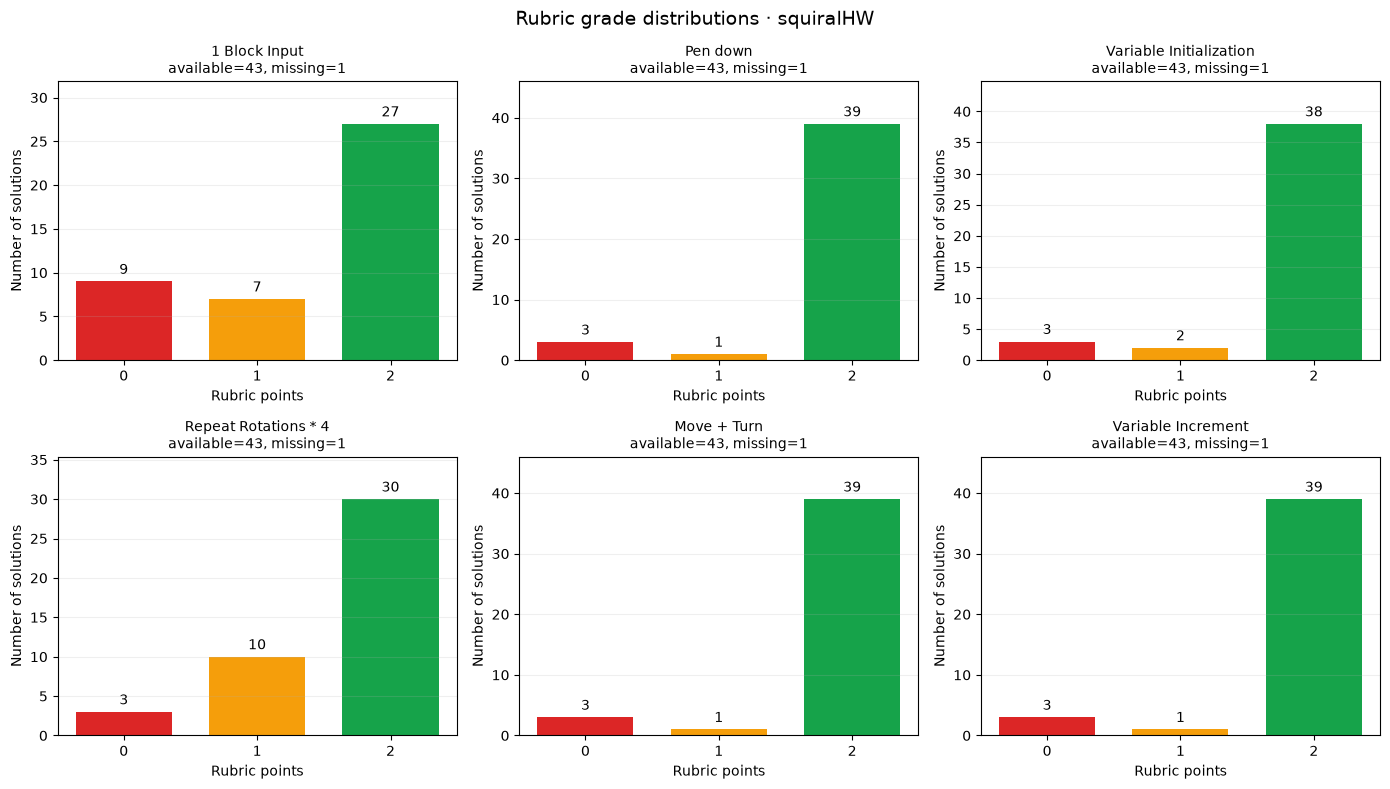

{'1 Block Input': {'0': 9, '1': 7, '2': 27, 'missing': 1},
 'Pen down': {'0': 3, '1': 1, '2': 39, 'missing': 1},
 'Variable Initialization': {'0': 3, '1': 2, '2': 38, 'missing': 1},
 'Repeat Rotations * 4': {'0': 3, '1': 10, '2': 30, 'missing': 1},
 'Move + Turn': {'0': 3, '1': 1, '2': 39, 'missing': 1},
 'Variable Increment': {'0': 3, '1': 1, '2': 39, 'missing': 1}}

In [46]:
import math

import matplotlib.pyplot as plt


rubric_grade_distributions = {}
histogram_columns = 3
histogram_rows = math.ceil(len(rubric_columns) / histogram_columns)
figure, axes = plt.subplots(
    histogram_rows,
    histogram_columns,
    figsize=(14, 4 * histogram_rows),
    squeeze=False,
)
axes = list(axes.flat)

for axis, rubric_name in zip(axes, rubric_columns):
    parsed_scores = [parse_score(row[rubric_name]) for row in rubric_rows]
    available_scores = [score for score in parsed_scores if score is not None]
    counts = [
        sum(score == grade for score in available_scores)
        for grade in (0.0, 1.0, 2.0)
    ]
    missing_count = len(parsed_scores) - len(available_scores)
    rubric_grade_distributions[rubric_name] = {
        "0": counts[0],
        "1": counts[1],
        "2": counts[2],
        "missing": missing_count,
    }

    bars = axis.bar(
        (0, 1, 2),
        counts,
        width=0.72,
        color=("#dc2626", "#f59e0b", "#16a34a"),
    )
    axis.bar_label(
        bars,
        labels=[str(count) if count else "" for count in counts],
        padding=3,
    )
    axis.set_title(
        f"{rubric_name}\n"
        f"available={len(available_scores)}, missing={missing_count}",
        fontsize=10,
    )
    axis.set_xticks((0, 1, 2), labels=("0", "1", "2"))
    axis.set_xlabel("Rubric points")
    axis.set_ylabel("Number of solutions")
    axis.set_ylim(0, max(max(counts), 1) * 1.18)
    axis.grid(axis="y", alpha=0.2)

for unused_axis in axes[len(rubric_columns):]:
    unused_axis.set_visible(False)

figure.suptitle(f"Rubric grade distributions · {TASK_ID}", fontsize=14)
figure.tight_layout()
plt.show()

rubric_grade_distributions

## Learn subtree-distance heatmaps by rubric

For every rubric criterion, use 2-point solutions as the full-credit group and 0/1-point solutions as the comparison group. The learner extracts every normalized subtree through `HEATMAP_MAX_DEPTH`, compares each positive candidate with its closest same-depth match in the other trees, and learns heat as `cohesion × separation`. Identical candidates and tree-edit distances are cached across rubrics.

In [47]:
FULL_CREDIT_SCORE = 2.0


full_credit_solutions_by_rubric = {}
lower_scoring_solutions_by_rubric = {}

for rubric_name in rubric_columns:
    full_credit_solutions = [
        solution
        for solution in solutions
        if solution["rubric_scores"].get(rubric_name) == FULL_CREDIT_SCORE
    ]
    lower_scoring_solutions = [
        solution
        for solution in solutions
        if solution["rubric_scores"].get(rubric_name) is not None
        and solution["rubric_scores"][rubric_name] < FULL_CREDIT_SCORE
    ]
    full_credit_solutions_by_rubric[rubric_name] = full_credit_solutions
    lower_scoring_solutions_by_rubric[rubric_name] = lower_scoring_solutions

rubric_heatmap_models, annotated_solutions = learn_rubric_heatmaps(
    solutions,
    rubric_columns,
    max_depth=HEATMAP_MAX_DEPTH,
    full_credit_score=FULL_CREDIT_SCORE,
    progress=print,
)

for rubric_name, model in rubric_heatmap_models.items():
    strongest = []
    seen_trees = set()
    for candidate in model.candidates:
        if candidate.tree in seen_trees:
            continue
        seen_trees.add(candidate.tree)
        strongest.append(candidate)
        if len(strongest) == 3:
            break
    print(f"\n{rubric_name}: top learned candidates")
    for candidate in strongest:
        print(
            f"  {candidate.candidate_id} "
            f"depth={candidate.depth} root={candidate.tree.name!r} "
            f"heat={candidate.heat:.3f} "
            f"high_distance={candidate.mean_high_distance:.3f} "
            f"low_distance={candidate.mean_low_distance:.3f}"
        )

Indexing 43 solutions through subtree depth 4
Unique normalized subtrees by depth: {1: 81, 2: 256, 3: 377, 4: 434}
Learned 1 Block Input: 27 full-credit, 16 lower-scoring, 924 unique candidates
Learned Pen down: 39 full-credit, 4 lower-scoring, 1074 unique candidates
Learned Variable Initialization: 38 full-credit, 5 lower-scoring, 1091 unique candidates
Learned Repeat Rotations * 4: 30 full-credit, 13 lower-scoring, 876 unique candidates
Learned Move + Turn: 39 full-credit, 4 lower-scoring, 1087 unique candidates
Learned Variable Increment: 39 full-credit, 4 lower-scoring, 1098 unique candidates
Applying learned candidates for 1 Block Input
Applying learned candidates for Pen down
Applying learned candidates for Variable Initialization
Applying learned candidates for Repeat Rotations * 4
Applying learned candidates for Move + Turn
Applying learned candidates for Variable Increment

1 Block Input: top learned candidates
  d1-b40471fc6d092e3d depth=1 root='doChangeVar' heat=0.384 high_d

## Visualize one student's snapshot for every rubric

The selected student's final snapshot is printed once for every rubric, with one AST node per row and children indented underneath their parent. Opcode text changes from gray through amber to red as its learned heat approaches 1. The number at the right is the exact, unscaled heat value, so colors remain comparable between rubric sections. Change `HEATMAP_STUDENT_ID` in the parameter cell to select another student's final snapshot.

In [48]:
from html import escape

from IPython.display import HTML, display


def heat_color(heat):
    """Map heat in [0, 1] from readable gray through amber to red."""
    heat = min(1.0, max(0.0, float(heat)))
    anchors = ((107, 114, 128), (245, 158, 11), (220, 38, 38))
    if heat <= 0.5:
        start, end, fraction = anchors[0], anchors[1], heat * 2
    else:
        start, end, fraction = anchors[1], anchors[2], (heat - 0.5) * 2
    red, green, blue = (
        round(left + (right - left) * fraction)
        for left, right in zip(start, end)
    )
    return f"#{red:02x}{green:02x}{blue:02x}"


def ordered_ast_children(node):
    children = node.get("children") or []
    if isinstance(children, list):
        return children
    if isinstance(children, dict):
        order = node.get("children-order") or list(children)
        return [children[key] for key in order if key in children]
    raise ValueError(f"Unexpected children value for node {node.get('type')!r}")


def render_ast_heatmap(ast, rubric_name):
    lines = []

    def append_node(node, depth=0):
        heat = float(node["rubric_heatmap"][rubric_name])
        best_depth = node["rubric_heatmap_best_depth"][rubric_name]
        best_candidate = node["rubric_heatmap_best_candidate"][rubric_name]
        label = str(node.get("type", "<missing type>"))
        if "value" in node:
            label += f" = {node['value']}"
        details = (
            f"heat={heat:.6f}; best depth={best_depth}; "
            f"candidate={best_candidate}"
        )
        indentation = "  " * depth
        weight = 500 + round(300 * heat)
        lines.append(
            f"{indentation}<span style=\"color:{heat_color(heat)};"
            f"font-weight:{weight}\" title=\"{escape(details, quote=True)}\">"
            f"{escape(label)}</span> "
            f"<span style=\"color:#64748b\">{heat:.3f}</span>"
        )
        for child in ordered_ast_children(node):
            append_node(child, depth + 1)

    append_node(ast)
    return (
        "<div style=\"font-family:system-ui,sans-serif;max-width:1100px\">"
        "<div style=\"display:flex;align-items:center;gap:10px;margin:8px 0\">"
        "<span style=\"font-size:12px;color:#64748b\">0</span>"
        "<span style=\"width:220px;height:10px;border-radius:5px;"
        "background:linear-gradient(90deg,#6b7280,#f59e0b,#dc2626)\"></span>"
        "<span style=\"font-size:12px;color:#64748b\">1</span>"
        "</div>"
        "<pre style=\"line-height:1.55;background:#f8fafc;border:1px solid #e2e8f0;"
        "border-radius:8px;padding:14px;overflow:auto\">"
        + "\n".join(lines)
        + "</pre></div>"
    )


selected_heatmap_solution = next(
    (
        solution
        for solution in annotated_solutions
        if solution["student_id"] == HEATMAP_STUDENT_ID
    ),
    None,
)
if selected_heatmap_solution is None:
    raise ValueError(
        f"Student {HEATMAP_STUDENT_ID!r} has no graded snapshot for {TASK_ID!r}."
    )
if selected_heatmap_solution["ast_heatmap"] is None:
    raise ValueError(f"Student {HEATMAP_STUDENT_ID!r} has no AST to visualize.")

selected_heatmap_html_by_rubric = {}
rubric_sections = []
for rubric_name in rubric_columns:
    rubric_html = render_ast_heatmap(
        selected_heatmap_solution["ast_heatmap"],
        rubric_name,
    )
    selected_heatmap_html_by_rubric[rubric_name] = rubric_html
    actual_score = selected_heatmap_solution["rubric_scores"][rubric_name]
    rubric_sections.append(
        "<section style=\"margin:0 0 28px\">"
        f"<h3 style=\"margin-bottom:4px\">{escape(rubric_name)}</h3>"
        f"<div style=\"color:#64748b;margin-bottom:6px\">"
        f"Actual score: {escape(str(actual_score))}</div>"
        f"{rubric_html}</section>"
    )

selected_heatmap_html = (
    "<div style=\"font-family:system-ui,sans-serif\">"
    f"<h2 style=\"margin-bottom:4px\">Student "
    f"{escape(selected_heatmap_solution['student_id'])}</h2>"
    f"<div style=\"color:#64748b;margin-bottom:18px\">"
    f"Code state: {escape(str(selected_heatmap_solution['code_state_id']))}"
    f"</div>{''.join(rubric_sections)}</div>"
)
print(
    f"Student: {selected_heatmap_solution['student_id']} | "
    f"code state: {selected_heatmap_solution['code_state_id']} | "
    f"rendered rubrics: {len(rubric_columns)}"
)
display(HTML(selected_heatmap_html))

Student: J7u.Zn25F3jN.IqS | code state: 13283 | rendered rubrics: 6


The original `solutions` list remains unchanged. `rubric_heatmap_models` contains the learned subtree candidates and distance summaries. Every record in `annotated_solutions` has an `ast_heatmap` copy whose nodes contain `rubric_heatmap`, `rubric_heatmap_best_depth`, and `rubric_heatmap_best_candidate`. The next cell previews the selected output without printing the complete AST.

In [49]:
if not solutions:
    raise ValueError(f"No graded solutions were built for {TASK_ID}")

preview_node = selected_heatmap_solution["ast_heatmap"]
{
    "solution": {
        key: value
        for key, value in selected_heatmap_solution.items()
        if key not in {"ast", "ast_heatmap"}
    },
    "root_type": preview_node["type"],
    "root_heatmap": preview_node["rubric_heatmap"],
    "root_best_depth": preview_node["rubric_heatmap_best_depth"],
}

{'solution': {'student_id': 'J7u.Zn25F3jN.IqS',
  'task_id': 'squiralHW',
  'project_id': '110dd5c3-db33-4c30-afab-b0443567617b',
  'code_state_id': '13283',
  'step_index': 86,
  'event_id': 47795,
  'timestamp': '2017-02-05T13:19:41',
  'rubric_scores': {'1 Block Input': 2.0,
   'Pen down': 2.0,
   'Variable Initialization': 2.0,
   'Repeat Rotations * 4': 2.0,
   'Move + Turn': 2.0,
   'Variable Increment': 2.0}},
 'root_type': 'snapshot',
 'root_heatmap': {'1 Block Input': 0.10085069444444444,
  'Pen down': 0.05194498438777207,
  'Variable Initialization': 0.03366067689310931,
  'Repeat Rotations * 4': 0.046740996258476386,
  'Move + Turn': 0.0408674976915974,
  'Variable Increment': 0.03871820700075549},
 'root_best_depth': {'1 Block Input': 2,
  'Pen down': 4,
  'Variable Initialization': 2,
  'Repeat Rotations * 4': 4,
  'Move + Turn': 2,
  'Variable Increment': 4}}